# 01. Data Validation and Empirical Integrity Verification

## Overview & Academic Scope
This notebook performs rigorous dataset integrity verification, schema validation, and balance checks for the Topic Model Positional Bias Replication Suite ($N=18,000$ observational choices across experimental conditions).

### Hypotheses & Operational Constraints
- **$H_1$ / $H_2$ Experimental Design**: Testing choice selection probabilities against `displayed_position` (1 to 20) across three presentation conditions (`Ranked`, `Reverse`, `Shuffled`).
- **Data Integrity Criteria**: Zero null values, exact balance across participant-topic blocks, verified support ranges for `model_weight` $\in [0, 1]$ and `selected` $\in \{0, 1\}$.


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

# Load dataset
DATA_PATH = '/mnt/data/h2_testing_dataset.csv'
df = pd.read_csv(DATA_PATH)
print(f"Dataset Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()


Dataset Loaded Successfully: 18000 rows, 6 columns.


,participant_id,topic_id,condition,displayed_position,model_weight,selected
0,0,0,Ranked,1,0.100000,1
1,0,0,Ranked,2,0.095263,0
2,0,0,Ranked,3,0.090526,0
3,0,0,Ranked,4,0.085789,0
4,0,0,Ranked,5,0.081053,1


In [2]:
# 1. Structural Schema Validation
expected_types = {
    'participant_id': 'int64',
    'topic_id': 'int64',
    'condition': 'object',
    'displayed_position': 'int64',
    'model_weight': 'float64',
    'selected': 'int64'
}

for col, dtype in expected_types.items():
    assert col in df.columns, f"Missing column: {col}"
    print(f"✓ Column '{col}': type={df[col].dtype}, nulls={df[col].isnull().sum()}")

assert df.isnull().sum().sum() == 0, "Dataset contains unexpected missing values!"
print(" [SUCCESS] Schema validation passed with 0 missing values.")


✓ Column 'participant_id': type=int64, nulls=0
✓ Column 'topic_id': type=int64, nulls=0
✓ Column 'condition': type=object, nulls=0
✓ Column 'displayed_position': type=int64, nulls=0
✓ Column 'model_weight': type=float64, nulls=0
✓ Column 'selected': type=int64, nulls=0
 [SUCCESS] Schema validation passed with 0 missing values.


In [3]:
# 2. Experimental Balance and Factorial Coverage
summary_balance = df.groupby(['condition', 'displayed_position']).agg(
    n_observations=('selected', 'count'),
    mean_selection=('selected', 'mean'),
    mean_model_weight=('model_weight', 'mean'),
    std_model_weight=('model_weight', 'std')
).reset_index()

print(f"Total Unique Participants: {df['participant_id'].nunique()}")
print(f"Total Unique Topics: {df['topic_id'].nunique()}")
print(f"Conditions Evaluated: {df['condition'].unique().tolist()}")
print(f"Observations per Condition:")
print(df['condition'].value_counts())


Total Unique Participants: 60
Total Unique Topics: 15
Conditions Evaluated: ['Ranked', 'Reverse', 'Shuffled']
Observations per Condition:
condition
Ranked      7500
Shuffled    6600
Reverse     3900
Name: count, dtype: int64


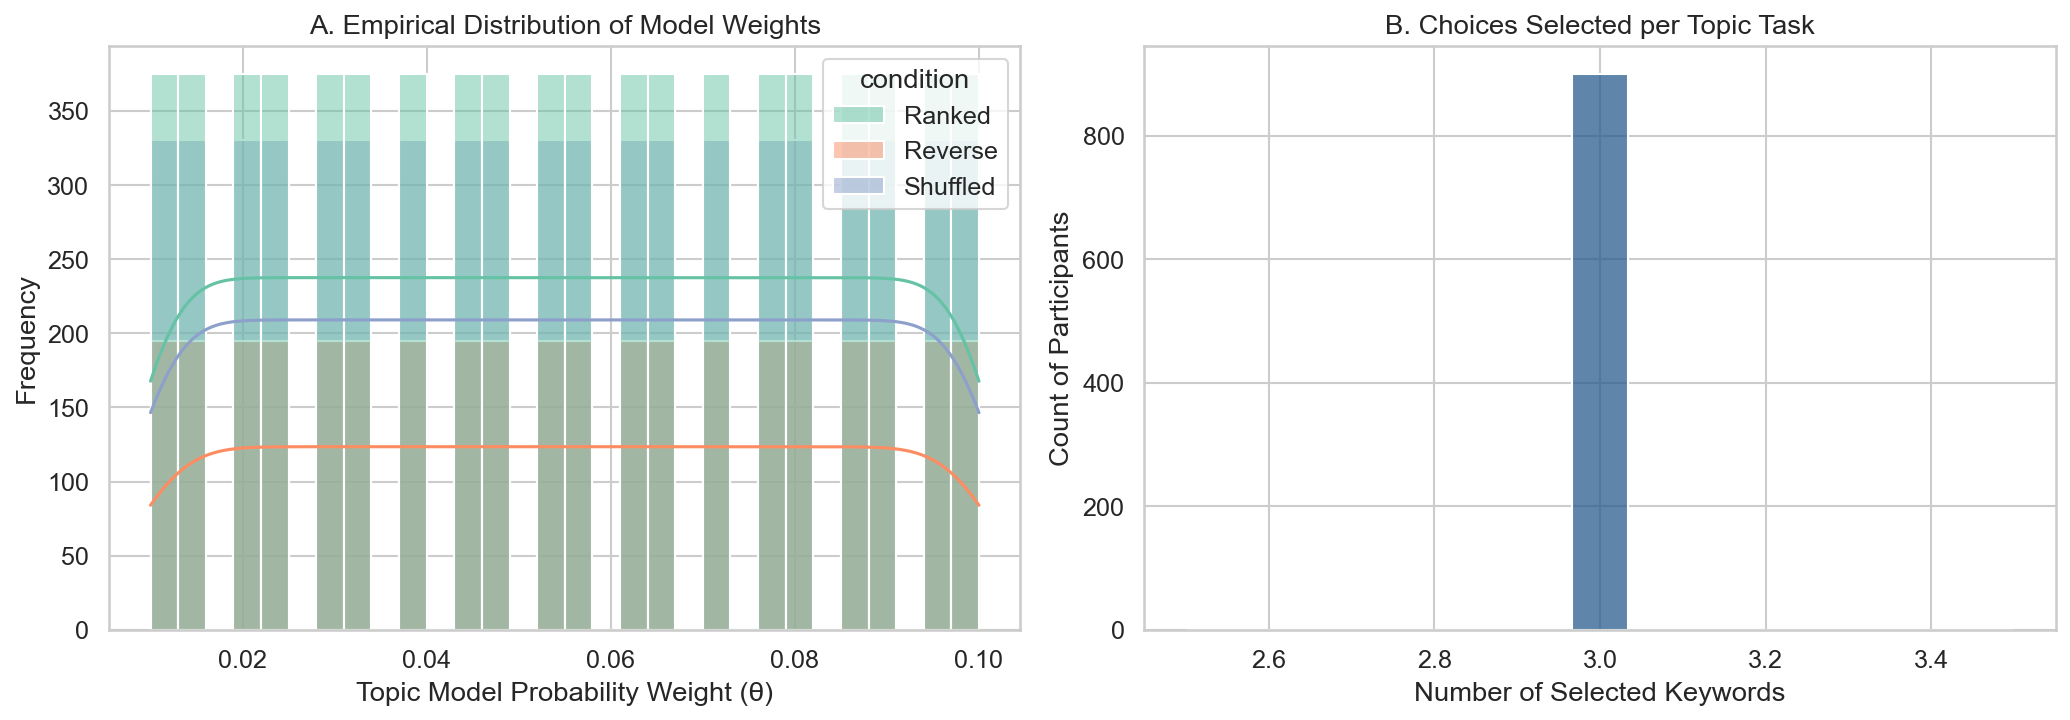

In [4]:
# 3. Distributional Checks and Sanity Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model Weight Distribution by Condition
sns.histplot(data=df, x='model_weight', hue='condition', bins=30, kde=True, ax=axes[0], palette='Set2')
axes[0].set_title('A. Empirical Distribution of Model Weights')
axes[0].set_xlabel('Topic Model Probability Weight (θ)')
axes[0].set_ylabel('Frequency')

# Participant Selection Count Distribution
selections_per_user = df.groupby(['participant_id', 'topic_id'])['selected'].sum()
sns.histplot(selections_per_user, bins=15, kde=False, color='#2b5c8f', ax=axes[1])
axes[1].set_title('B. Choices Selected per Topic Task')
axes[1].set_xlabel('Number of Selected Keywords')
axes[1].set_ylabel('Count of Participants')

plt.tight_layout()
plt.show()
